In [ ]:
"""
Transformer Dynamics Model for Procgen World Model
"""

In [ ]:
#Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

In [ ]:
"""
Positional Encoding
"""

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_temporal=20, spatial_positions=65):
        """
        Args:
            d_model: embedding dimension
            max_temporal: maximum number of timesteps (frames) in a sequence
            spatial_positions: 64 frame token positions + 1 action position = 65
        """
        super().__init__()
        self.temporal_embed = nn.Embedding(max_temporal, d_model)
        self.spatial_embed = nn.Embedding(spatial_positions, d_model)

    def forward(self, temporal_ids, spatial_ids):
        """
        Args:
            temporal_ids: [B, seq_len] — which timestep each token belongs to
            spatial_ids: [B, seq_len] — position within the frame (0-63) or action (64)
        Returns:
            [B, seq_len, d_model] positional embeddings
        """
        return self.temporal_embed(temporal_ids) + self.spatial_embed(spatial_ids)

In [ ]:
"""
Transformer Block
"""

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, causal_mask=None):
        # Self-attention with residual connection
        attn_out, _ = self.attention(x, x, x, attn_mask=causal_mask)
        x = self.norm1(x + attn_out)

        # Feed-forward with residual connection
        x = self.norm2(x + self.ffn(x))
        return x

In [ ]:
"""
World Model Transformer
"""

In [ ]:
class WorldModelTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=512,
        num_actions=15,
        d_model=256,           # IRIS fix: Reduced from 384
        n_heads=8,
        n_layers=4,            # IRIS fix: Reduced from 8 to stop memorization
        d_ff=1024,             # IRIS fix: Reduced from 1536
        context_frames=4,
        tokens_per_frame=64,
        dropout=0.3,           # IRIS fix: Increased from 0.1 to 0.3
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_actions = num_actions
        self.d_model = d_model
        self.context_frames = context_frames
        self.tokens_per_frame = tokens_per_frame

        self.total_vocab = vocab_size + num_actions
        self.token_embed = nn.Embedding(self.total_vocab, d_model)
        self.pos_encoding = PositionalEncoding(
            d_model,
            max_temporal=context_frames + 1,
            spatial_positions=tokens_per_frame + 1,
        )

        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.output_head = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self._causal_mask = None

        self.apply(self._init_weights) # IRIS fix: Proper weight initialization

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)

    def _get_causal_mask(self, seq_len, device):
        if self._causal_mask is None or self._causal_mask.shape[0] < seq_len:
            mask = torch.triu(torch.ones(seq_len, seq_len, device=device) * float('-inf'), diagonal=1)
            self._causal_mask = mask
        return self._causal_mask[:seq_len, :seq_len]

    def _build_sequence(self, tokens, actions):
        B, T, K = tokens.shape
        sequences, temporal, spatial = [], [], []

        for t in range(T):
            sequences.append(tokens[:, t, :])
            temporal.append(torch.full((B, K), t, device=tokens.device))
            spatial.append(torch.arange(K, device=tokens.device).unsqueeze(0).expand(B, -1))

            # Action Shift Fix: Ensure actions map perfectly to the visual frames
            if t < T - 1:
                act_toks = actions[:, t].unsqueeze(1) + self.vocab_size
                sequences.append(act_toks)
                temporal.append(torch.full((B, 1), t, device=tokens.device))
                spatial.append(torch.full((B, 1), K, device=tokens.device))

        return torch.cat(sequences, dim=1), torch.cat(temporal, dim=1), torch.cat(spatial, dim=1)

    def forward(self, tokens, actions):
        input_ids, temporal_ids, spatial_ids = self._build_sequence(tokens, actions)
        x = self.token_embed(input_ids)
        x = x + self.pos_encoding(temporal_ids, spatial_ids)
        x = self.dropout(x)

        seq_len = x.shape[1]
        causal_mask = self._get_causal_mask(seq_len, x.device)

        for block in self.transformer_blocks:
            x = block(x, causal_mask)

        return self.output_head(x)

    @torch.no_grad()
    def predict_next_frame(self, context_tokens, context_actions, temperature=1.0):
        # Temperature sampling added to fix Argmax mode collapse
        self.eval()
        B = context_tokens.shape[0]
        device = context_tokens.device
        generated = []

        for i in range(self.tokens_per_frame):
            if len(generated) == 0:
                all_tokens = context_tokens
            else:
                partial = torch.zeros(B, 1, self.tokens_per_frame, dtype=torch.long, device=device)
                for j, g in enumerate(generated):
                    partial[:, 0, j] = g
                all_tokens = torch.cat([context_tokens, partial], dim=1)

            all_actions = context_actions

            logits = self.forward(all_tokens, all_actions)
            pred_pos = context_tokens.shape[1] * (self.tokens_per_frame + 1) - 1 + i

            # IRIS/GPT Fix: Categorical Sampling instead of Argmax
            next_token_logits = logits[:, pred_pos, :] / temperature
            probs = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).squeeze(-1)

            generated.append(next_token)

        return torch.stack(generated, dim=1)

In [ ]:
"""
Quick Test
"""

In [ ]:
# if __name__ == "__main__":
#     model = WorldModelTransformer(
#         vocab_size=512,
#         num_actions=15,
#         d_model=256,
#         n_heads=8,
#         n_layers=4,
#         d_ff=1536,
#         context_frames=4,
#     )

#     total_params = sum(p.numel() for p in model.parameters())
#     print(f"Transformer parameters: {total_params:,}")

#     # Fake input: 4 context frames + 1 target frame = 5 frames, 4 actions
#     B = 4
#     tokens = torch.randint(0, 512, (B, 5, 64))  # 5 frames
#     actions = torch.randint(0, 15, (B, 4))        # 4 actions

#     logits = model(tokens, actions)

#     print(f"Input tokens shape:   {tokens.shape}")    # [4, 5, 64]
#     print(f"Actions shape:        {actions.shape}")    # [4, 4]
#     print(f"Output logits shape:  {logits.shape}")     # [4, seq_len, 512]

#     # Sequence length: 5 frames * 64 tokens + 4 actions = 324
#     print(f"Sequence length:      {logits.shape[1]}")
#     print(f"\nThe model sees {tokens.shape[1]-1} past frames + actions")
#     print(f"and predicts the {tokens.shape[1]}th frame's tokens")


Transformer parameters: 4,494,080
Input tokens shape:   torch.Size([4, 5, 64])
Actions shape:        torch.Size([4, 4])
Output logits shape:  torch.Size([4, 324, 512])
Sequence length:      324

The model sees 4 past frames + actions
and predicts the 5th frame's tokens


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")

!cp -r /content/drive/MyDrive/procgen_tokenized /content/procgen_tokenized
print("Tokenized data copied to local disk!")

TOKEN_DIR = "/content/procgen_tokenized"
SAVE_DIR = "/content/drive/MyDrive/transformer_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

Using device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Tokenized data copied to local disk!


In [ ]:
class TokenSequenceDataset(Dataset):
    def __init__(self, h5_path, context_frames=4):
        self.context_frames = context_frames
        self.seq_len = context_frames + 1  # context + 1 target frame

        with h5py.File(h5_path, "r") as f:
            self.tokens = f["tokens"][:]    # [N, 8, 8]
            self.actions = f["actions"][:]  # [N]
            self.dones = f["dones"][:]      # [N]

        # Flatten tokens from [N, 8, 8] to [N, 64]
        self.tokens = self.tokens.reshape(len(self.tokens), -1)  # [N, 64]

        # Find valid start indices
        self.valid_indices = self._find_valid_indices()
        print(f"  {os.path.basename(h5_path)}: {len(self.tokens)} frames, "
              f"{len(self.valid_indices)} valid sequences")

    def _find_valid_indices(self):
        """Find indices where we can extract a full sequence within one episode."""
        valid = []
        n = len(self.tokens)
        for i in range(n - self.seq_len):
            # Check that no done=True occurs within the sequence
            if not self.dones[i:i + self.seq_len - 1].any():
                valid.append(i)
        return np.array(valid)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start = self.valid_indices[idx]
        end = start + self.seq_len

        tokens = torch.tensor(self.tokens[start:end], dtype=torch.long)    # [seq_len, 64]
        actions = torch.tensor(self.actions[start:end-1], dtype=torch.long) # [seq_len-1]

        return tokens, actions

In [ ]:
# Training data
coinrun_data = TokenSequenceDataset(
    os.path.join(TOKEN_DIR, "coinrun_train_tokens.h5"), context_frames=4
)
starpilot_data = TokenSequenceDataset(
    os.path.join(TOKEN_DIR, "starpilot_train_tokens.h5"), context_frames=4
)
combined_train = torch.utils.data.ConcatDataset([coinrun_data, starpilot_data])

train_loader = DataLoader(
    combined_train,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)

# Validation data (unseen levels — used to detect overfitting)
coinrun_val = TokenSequenceDataset(
    os.path.join(TOKEN_DIR, "coinrun_test_tokens.h5"), context_frames=4
)
starpilot_val = TokenSequenceDataset(
    os.path.join(TOKEN_DIR, "starpilot_test_tokens.h5"), context_frames=4
)
combined_val = torch.utils.data.ConcatDataset([coinrun_val, starpilot_val])

val_loader = DataLoader(
    combined_val,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)

print(f"\nTrain sequences:  {len(combined_train):,}")
print(f"Val sequences:    {len(combined_val):,}")
print(f"Train batches:    {len(train_loader)}")
print(f"Val batches:      {len(val_loader)}")

  coinrun_train_tokens.h5: 100000 frames, 99343 valid sequences
  starpilot_train_tokens.h5: 100000 frames, 95047 valid sequences
  coinrun_test_tokens.h5: 20000 frames, 19875 valid sequences
  starpilot_test_tokens.h5: 20000 frames, 18947 valid sequences

Train sequences:  194,390
Val sequences:    38,822
Train batches:    6074
Val batches:      1213


In [ ]:
model = WorldModelTransformer(
    vocab_size=512,
    num_actions=15,
    d_model=256,
    n_heads=8,
    n_layers=6,
    d_ff=1536,
    context_frames=4,
    dropout=0.2,
).to(device)

# Weight decay helps regularize — penalizes large weights
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

# Cosine schedule from the start this time
NUM_EPOCHS = 60
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

total_params = sum(p.numel() for p in model.parameters())
print(f"Transformer parameters: {total_params:,}")
print(f"Optimizer: AdamW, lr=3e-4, weight_decay=0.01")
print(f"Scheduler: Cosine annealing over {NUM_EPOCHS} epochs")

Transformer parameters: 6,598,912
Optimizer: AdamW, lr=3e-4, weight_decay=0.01
Scheduler: Cosine annealing over 60 epochs


In [ ]:
tokens_per_frame = 64

def get_frame_mask(seq_len, context_frames, tokens_per_frame):
    """Create a boolean mask that's True for frame token positions."""
    mask = torch.zeros(seq_len, dtype=torch.bool)
    pos = 0
    for t in range(context_frames + 1):
        mask[pos:pos + tokens_per_frame] = True
        pos += tokens_per_frame
        if t < context_frames:
            pos += 1
    return mask

@torch.no_grad()
def evaluate_val(model, val_loader):
    """Compute loss and accuracy on the validation set."""
    model.eval()
    total_loss = 0
    total_correct = 0
    total_tokens = 0

    for tokens, actions in val_loader:
        tokens = tokens.to(device)
        actions = actions.to(device)

        logits = model(tokens, actions)
        seq_len = logits.shape[1]

        input_ids, _, _ = model._build_sequence(tokens, actions)
        target = input_ids[:, 1:]
        pred = logits[:, :-1, :]

        frame_mask = get_frame_mask(seq_len, model.context_frames, tokens_per_frame)
        frame_mask = frame_mask[:-1]
        target_is_frame = target < model.vocab_size
        loss_mask = frame_mask.to(device) & target_is_frame

        pred_flat = pred.reshape(-1, model.vocab_size)
        target_flat = target.reshape(-1)
        mask_flat = loss_mask.reshape(-1)

        loss = F.cross_entropy(pred_flat[mask_flat], target_flat[mask_flat], label_smoothing=0.1)
        total_loss += loss.item()

        predicted_ids = pred_flat[mask_flat].argmax(dim=-1)
        total_correct += (predicted_ids == target_flat[mask_flat]).sum().item()
        total_tokens += mask_flat.sum().item()

    avg_loss = total_loss / len(val_loader)
    avg_acc = total_correct / total_tokens if total_tokens > 0 else 0
    return avg_loss, avg_acc

In [18]:
SAVE_DIR = "/content/drive/MyDrive/transformer_checkpoints_v3"
os.makedirs(SAVE_DIR, exist_ok=True)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [],
}

best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0
PATIENCE = 10  # stop if val loss doesn't improve for 8 epochs

for epoch in range(NUM_EPOCHS):
    # === Training ===
    model.train()
    epoch_loss = 0
    epoch_correct = 0
    epoch_total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for tokens, actions in pbar:
        tokens = tokens.to(device)
        actions = actions.to(device)

        logits = model(tokens, actions)
        B = tokens.shape[0]
        seq_len = logits.shape[1]

        input_ids, _, _ = model._build_sequence(tokens, actions)
        target = input_ids[:, 1:]
        pred = logits[:, :-1, :]

        frame_mask = get_frame_mask(seq_len, model.context_frames, tokens_per_frame)
        frame_mask = frame_mask[:-1]
        target_is_frame = target < model.vocab_size
        loss_mask = frame_mask.to(device) & target_is_frame

        pred_flat = pred.reshape(-1, model.vocab_size)
        target_flat = target.reshape(-1)
        mask_flat = loss_mask.reshape(-1)

        loss = F.cross_entropy(pred_flat[mask_flat], target_flat[mask_flat], label_smoothing=0.1)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            predicted_ids = pred_flat[mask_flat].argmax(dim=-1)
            correct = (predicted_ids == target_flat[mask_flat]).sum().item()
            total = mask_flat.sum().item()
            epoch_correct += correct
            epoch_total += total

        epoch_loss += loss.item()
        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{correct/total:.3f}" if total > 0 else "N/A",
        })

    # === Validation ===
    val_loss, val_acc = evaluate_val(model, val_loader)

    # === Step the Scheduler ===
    # This must be fed the val_loss so it knows when to drop the learning rate
    scheduler.step()

    # === Track ===
    train_loss = epoch_loss / len(train_loader)
    train_acc = epoch_correct / epoch_total if epoch_total > 0 else 0

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.3f} | lr={current_lr:.6f}")

    # === Early stopping check ===
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        # Save best model
        best_path = os.path.join(SAVE_DIR, "transformer_best.pt")
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }, best_path)
        print(f" val_loss={val_loss:.4f} (saved)")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}. Best was epoch {best_epoch}.")
            break

    # Save checkpoint every 5 epochs regardless
    if (epoch + 1) % 5 == 0:
        ckpt_path = os.path.join(SAVE_DIR, f"transformer_epoch{epoch+1}.pt")
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
        }, ckpt_path)

print(f"\nBest model: epoch {best_epoch} with val_loss={best_val_loss:.4f}")

Epoch 1/60: 100%|██████████| 6074/6074 [02:39<00:00, 38.02it/s, loss=1.8793, acc=0.646]


Epoch 1: train_loss=2.0862 train_acc=0.606 | val_loss=1.7951 val_acc=0.685 | lr=0.000300
 val_loss=1.7951 (saved)


Epoch 2/60: 100%|██████████| 6074/6074 [02:39<00:00, 38.18it/s, loss=1.8159, acc=0.667]


Epoch 2: train_loss=1.7616 train_acc=0.691 | val_loss=1.7362 val_acc=0.707 | lr=0.000299
 val_loss=1.7362 (saved)


Epoch 3/60: 100%|██████████| 6074/6074 [02:39<00:00, 38.10it/s, loss=1.7070, acc=0.702]


...

Epoch 58: train_loss=1.4673 train_acc=0.795 | val_loss=1.6436 val_acc=0.752 | lr=0.000011
  No improvement (3/10)


Epoch 59/60: 100%|██████████| 6074/6074 [02:39<00:00, 38.09it/s, loss=1.4692, acc=0.791]


Epoch 59: train_loss=1.4670 train_acc=0.795 | val_loss=1.6429 val_acc=0.752 | lr=0.000010
 val_loss=1.6429 (saved)


Epoch 60/60: 100%|██████████| 6074/6074 [02:39<00:00, 38.04it/s, loss=1.4676, acc=0.798]


Epoch 60: train_loss=1.4668 train_acc=0.795 | val_loss=1.6439 val_acc=0.752 | lr=0.000010
  No improvement (1/10)

Best model: epoch 59 with val_loss=1.6429


In [19]:
# Save final model
final_path = os.path.join(SAVE_DIR, "transformer_best.pt")
torch.save({
    "epoch": NUM_EPOCHS,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "history": history,
}, final_path)
print(f"\nTraining complete. Saved to {final_path}")


Training complete. Saved to /content/drive/MyDrive/transformer_checkpoints_v3/transformer_best.pt


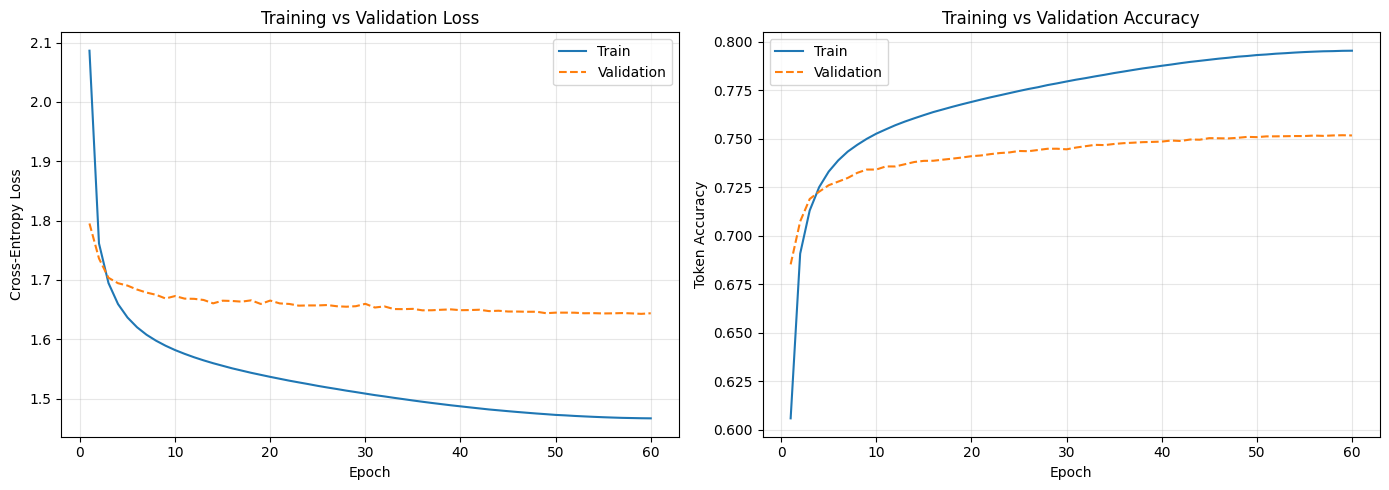

Best epoch: 59 (val_loss=1.6429)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history["train_loss"]) + 1)

# Loss: train vs val
axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"], label="Validation", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy: train vs val
axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"], label="Validation", linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Token Accuracy")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves_v2.png"), dpi=150)
plt.show()

print(f"Best epoch: {best_epoch} (val_loss={best_val_loss:.4f})")